# 🤖 Módulo Extra: Introducción al AutoML con TPOT
### Curso: **Machine Learning con Python** (IFCD093PO)
**Duración estimada:** 2 horas

---

## 🎯 Objetivos del Módulo

En este módulo especial, exploraremos cómo automatizar gran parte del flujo de trabajo de Machine Learning que hemos aprendido.

- ✅ Entender qué es el **AutoML** (Machine Learning Automatizado).
- ✅ Conocer **TPOT**, una herramienta potente basada en algoritmos genéticos.
- ✅ Usar TPOT para **encontrar automáticamente el mejor modelo** para un conjunto de datos.
- ✅ Exportar el código generado por TPOT para usarlo en nuestros proyectos.

---

## 📚 Tabla de Contenidos

1. [¿Qué es AutoML?](#1-que-es-automl)
2. [Introducción a TPOT](#2-intro-tpot)
3. [Caso Práctico: Clasificación de Dígitos](#3-caso-practico)
   - [Instalación y Carga de Datos](#3.1-datos)
   - [Búsqueda del Mejor Modelo](#3.2-busqueda)
   - [Evaluación y Exportación](#3.3-exportacion)
4. [Ejercicios Prácticos](#4-ejercicios)

---

## 🧠 1. ¿Qué es AutoML? <a id='1-que-es-automl'></a>

**AutoML (Automated Machine Learning)** es el proceso de automatizar las tareas repetitivas y complejas del desarrollo de modelos de Machine Learning.

Hasta ahora, hemos tenido que:
1.  Limpiar los datos.
2.  Seleccionar características.
3.  Elegir un modelo (SVM, Random Forest, etc.).
4.  Ajustar sus hiperparámetros.
5.  Validar el modelo.

¡AutoML intenta hacer los pasos 2, 3 y 4 por nosotros! No reemplaza al Data Scientist, pero **acelera el trabajo** al encontrar rápidamente un modelo base muy competitivo.

---

## 🧬 2. Introducción a TPOT <a id='2-intro-tpot'></a>

**TPOT (Tree-based Pipeline Optimization Tool)** es una librería de Python que utiliza **algoritmos genéticos** para encontrar el mejor pipeline de ML.

### ¿Cómo funciona?
Imagina que TPOT crea cientos de "pipelines" (combinaciones de preprocesadores y modelos) aleatorios. Luego:
1.  Los prueba todos.
2.  Selecciona los mejores (los que tienen mejor *accuracy*).
3.  Los "cruza" y "muta" (cambia parámetros, añade pasos) para crear una nueva generación mejorada.
4.  Repite esto durante varias generaciones.

Al final, te da **el mejor código de Python** para resolver tu problema.

![TPOT Process](https://raw.githubusercontent.com/EpistasisLab/tpot/master/images/tpot-logo.jpg)

---

# TPOT2 + MLflow - Versión Moderna

Este proyecto demuestra cómo usar **TPOT2** (la versión moderna y mejorada de TPOT) combinado con **MLflow** para AutoML en el dataset de dígitos de scikit-learn.

## 🆕 ¿Qué hay de nuevo en TPOT2?

TPOT2 es una **reescritura completa desde cero** con mejoras significativas:

### Nuevas características principales:
- ✅ **Multi-objective optimization**: Optimiza múltiples objetivos simultáneamente (ej: accuracy + complejidad)
- ✅ **Graph-based pipelines**: Representación más flexible con grafos en lugar de árboles
- ✅ **Genetic feature selection**: Selección evolutiva de características integrada
- ✅ **Steady-state algorithm**: Algoritmo evolutivo continuo (sin generaciones)
- ✅ **Better parallelization**: Mejor uso de Dask para procesamiento distribuido
- ✅ **Configurable search spaces**: Mayor flexibilidad para definir espacios de búsqueda
- ✅ **Early stopping mejorado**: Detección inteligente de convergencia
- ✅ **Bug fixes**: Corrige problemas de timeouts y evaluaciones infinitas de TPOT1

### Diferencias clave vs TPOT1:
| Característica | TPOT1 | TPOT2 |
|---------------|-------|-------|
| Arquitectura | Árbol | Grafo dirigido |
| Multi-objetivo | No | Sí ✅ |
| Feature selection genética | No | Sí ✅ |
| Algoritmo steady-state | No | Sí ✅ |
| Configuración | Dict rígido | ConfigSpace flexible |
| Pareto front | No | Sí ✅ |
| API simplificada | No | Sí ✅ |


## 🚀 3. Caso Práctico: Clasificación de Dígitos <a id='3-caso-practico'></a>

Vamos a usar el famoso dataset de dígitos manuscritos (como el MNIST pero más pequeño, incluido en Scikit-learn) para ver qué modelo encuentra TPOT.


### 1. Primer ejemplo (Básico)
Script de introducción que usa la API simplificada de TPOT2:
- Usa `TPOTClassifier` con valores por defecto optimizados
- No requiere especificar generations/population_size
- Integración completa con MLflow
- Perfecto para empezar

**Características:**
```python
# API simplificada - solo especifica lo esencial
tpot2.TPOTClassifier(
    max_time_mins=10,
    scorers=['accuracy'],
    cv=5,
    n_jobs=-1
)
```

## 🚀 Instalación


In [5]:
# Instalar con pip
%pip install -r requirementstpot2.txt


INFO: pip is looking at multiple versions of dask-ml to determine which version is compatible with other requirements. This could take a while.

   ---------- ----------------------------- 1/4 [sparse]
   ---------- ----------------------------- 1/4 [sparse]
   ------------------------------ --------- 3/4 [dask-ml]
   ---------------------------------------- 4/4 [dask-ml]



In [ ]:
# O con conda (recomendado para lightgbm)
%conda create -n tpot2 python=3.10
%conda activate tpot2
%conda install -c conda-forge lightg

In [8]:
"""
TPOT2 + MLflow - Versión Simple y Robusta
==========================================
Esta versión evita problemas comunes de workers usando configuración segura.
"""

import os
os.environ['LOKY_MAX_CPU_COUNT'] = '2'  # Limitar workers

import mlflow
import mlflow.sklearn
import tpot2
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import warnings
warnings.filterwarnings('ignore')


def main():
    """Función principal"""
    
    # Configurar MLflow
    mlflow.set_experiment("TPOT2_Digits_Simple")
    
    # Cargar el dataset de dígitos
    print("="*70)
    print("TPOT2 + MLflow - Dataset de Dígitos")
    print("="*70)
    print("\nCargando dataset de dígitos...")
    digits = load_digits()
    X = digits.data
    y = digits.target
    
    print(f"Dimensiones del dataset: {X.shape}")
    print(f"Número de clases: {len(np.unique(y))}")
    
    # Dividir en train y test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
    
    # Iniciar run de MLflow
    with mlflow.start_run(run_name="TPOT2_Simple_Run"):
        
        # Registrar parámetros del dataset
        mlflow.log_param("dataset", "digits")
        mlflow.log_param("n_samples", X.shape[0])
        mlflow.log_param("n_features", X.shape[1])
        mlflow.log_param("n_classes", len(np.unique(y)))
        mlflow.log_param("test_size", 0.2)
        mlflow.log_param("tpot_version", "2")
        
        # Configurar TPOT2 de forma simple y segura
        print("\n" + "="*70)
        print("Configurando TPOT2...")
        print("="*70)
        
        tpot = tpot2.TPOTClassifier(
            scorers=['accuracy'],
            cv=3,  # Menos folds = más rápido
            max_time_mins=5,  # Reducido para prueba rápida
            max_eval_time_mins=2,
            n_jobs=1,  # Un solo job evita problemas de workers
            random_state=42,
            verbose=1,
            memory_limit='2GB'
        )
        
        # Registrar configuración
        mlflow.log_param("tpot2_cv", 3)
        mlflow.log_param("tpot2_max_time_mins", 5)
        mlflow.log_param("tpot2_n_jobs", 1)
        
        # Entrenar TPOT2
        print("\n" + "="*70)
        print("Iniciando optimización con TPOT2...")
        print("Esto puede tardar unos minutos...")
        print("="*70 + "\n")
        
        tpot.fit(X_train, y_train)
        
        print("\n" + "="*70)
        print("✓ Optimización completada!")
        print("="*70)
        
        # Obtener el mejor pipeline
        print("\nMejor pipeline encontrado:")
        print(tpot.fitted_pipeline_)
        
        # Hacer predicciones
        y_pred_train = tpot.predict(X_train)
        y_pred_test = tpot.predict(X_test)
        
        # Calcular métricas
        train_accuracy = accuracy_score(y_train, y_pred_train)
        test_accuracy = accuracy_score(y_test, y_pred_test)
        
        print(f"\n{'='*70}")
        print("RESULTADOS:")
        print("="*70)
        print(f"Accuracy en train: {train_accuracy:.4f}")
        print(f"Accuracy en test:  {test_accuracy:.4f}")
        print(f"Overfitting gap:   {train_accuracy - test_accuracy:.4f}")
        
        # Registrar métricas en MLflow
        mlflow.log_metric("train_accuracy", train_accuracy)
        mlflow.log_metric("test_accuracy", test_accuracy)
        mlflow.log_metric("overfitting_gap", train_accuracy - test_accuracy)
        
        # Registrar el reporte de clasificación
        print("\n" + "="*70)
        print("REPORTE DE CLASIFICACIÓN:")
        print("="*70)
        report = classification_report(y_test, y_pred_test)
        print(report)
        
        # Guardar reporte como artifact
        report_path = "classification_report_simple.txt"
        with open(report_path, "w") as f:
            f.write("TPOT2 Classification Report\n")
            f.write("="*50 + "\n\n")
            f.write(report)
        mlflow.log_artifact(report_path)
        
        # Guardar matriz de confusión
        conf_matrix = confusion_matrix(y_test, y_pred_test)
        conf_path = "confusion_matrix_simple.csv"
        np.savetxt(conf_path, conf_matrix, delimiter=",", fmt="%d")
        mlflow.log_artifact(conf_path)
        
        # Guardar el mejor pipeline usando pickle/joblib
        print("\n" + "="*70)
        print("Guardando pipeline...")
        print("="*70)
        
        import pickle
        
        # Guardar el pipeline completo
        pipeline_path = 'tpot2_pipeline_simple.pkl'
        with open(pipeline_path, 'wb') as f:
            pickle.dump(tpot.fitted_pipeline_, f)
        mlflow.log_artifact(pipeline_path)
        print(f"✓ Pipeline guardado como: {pipeline_path}")
        
        # También guardar como código Python para referencia
        pipeline_code_path = 'tpot2_pipeline_simple.py'
        with open(pipeline_code_path, 'w') as f:
            f.write("# Pipeline encontrado por TPOT2\n")
            f.write("# Para usar este pipeline:\n")
            f.write("# 1. import pickle\n")
            f.write("# 2. with open('tpot2_pipeline_simple.pkl', 'rb') as f:\n")
            f.write("#        pipeline = pickle.load(f)\n")
            f.write("# 3. predictions = pipeline.predict(X_new)\n\n")
            f.write(f"# Pipeline: {tpot.fitted_pipeline_}\n")
        mlflow.log_artifact(pipeline_code_path)
        print(f"✓ Código de referencia: {pipeline_code_path}")
        
        # Información adicional
        if hasattr(tpot, 'evaluated_individuals'):
            n_evaluated = len(tpot.evaluated_individuals)
            mlflow.log_param("total_pipelines_evaluated", n_evaluated)
            print(f"\nTotal de pipelines evaluados: {n_evaluated}")
        
        # Registrar el modelo en MLflow
        print("\n" + "="*70)
        print("Registrando modelo en MLflow...")
        print("="*70)
        
        mlflow.sklearn.log_model(
            tpot.fitted_pipeline_,
            "model",
            registered_model_name="TPOT2_Digits_Simple"
        )
        
        # Registrar información adicional del pipeline
        mlflow.set_tag("best_pipeline", str(tpot.fitted_pipeline_)[:500])
        
        # Calcular score manualmente (TPOT2 no tiene método score())
        test_score = accuracy_score(y_test, y_pred_test)
        mlflow.set_tag("test_score", str(test_score))
        
        print("\n" + "="*70)
        print("✓ Experimento completado y registrado en MLflow")
        print(f"✓ Run ID: {mlflow.active_run().info.run_id}")
        print("="*70)
    
    print("\n" + "="*70)
    print("Para ver los resultados en MLflow UI, ejecuta:")
    print("  mlflow ui")
    print("Luego abre http://localhost:5000 en tu navegador")
    print("="*70 + "\n")


if __name__ == "__main__":
    main()

TPOT2 + MLflow - Dataset de Dígitos

Cargando dataset de dígitos...
Dimensiones del dataset: (1797, 64)
Número de clases: 10
Train size: 1437, Test size: 360

Configurando TPOT2...

Iniciando optimización con TPOT2...
Esto puede tardar unos minutos...



Generation: : 1it [05:02, 302.97s/it]



✓ Optimización completada!

Mejor pipeline encontrado:
Pipeline(steps=[('maxabsscaler', MaxAbsScaler()),
                ('selectfwe', SelectFwe(alpha=0.0005115425765)),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('lgbmclassifier',
                 LGBMClassifier(max_depth=5, n_estimators=71, n_jobs=1,
                                num_leaves=121, random_state=42, verbose=-1))])

RESULTADOS:
Accuracy en train: 1.

2026/02/15 14:50:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✓ Código de referencia: tpot2_pipeline_simple.py

Total de pipelines evaluados: 50

Registrando modelo en MLflow...

✓ Experimento completado y registrado en MLflow
✓ Run ID: 963513c4b88a4da788274e805105b6a7

Para ver los resultados en MLflow UI, ejecuta:
  mlflow ui
Luego abre http://localhost:5000 en tu navegador



Registered model 'TPOT2_Digits_Simple' already exists. Creating a new version of this model...
Created version '2' of model 'TPOT2_Digits_Simple'.


In [9]:
"""
Cómo cargar y usar pipelines guardados de TPOT2
================================================

En TPOT2, los pipelines se guardan con pickle/joblib, NO con export().
Este script muestra cómo cargar y usar un pipeline guardado.
"""

import pickle
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print("="*70)
print("Cómo cargar y usar pipelines de TPOT2")
print("="*70)

# Primero, simulemos que tenemos un pipeline guardado
# (en la práctica, este archivo lo habrías generado con TPOT2)
print("\n1. Supongamos que ya entrenaste TPOT2 y guardaste el pipeline")
print("   con: pickle.dump(tpot.fitted_pipeline_, file)")

# Cargar datos para demostración
digits = load_digits()
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
)

print("\n" + "="*70)
print("2. CARGAR EL PIPELINE GUARDADO")
print("="*70)

# OPCIÓN 1: Cargar con pickle (recomendado para TPOT2)
print("\nOpción 1: Usando pickle")
print("-" * 40)

try:
    # Intentar cargar un pipeline previamente guardado
    with open('tpot2_pipeline_simple.pkl', 'rb') as f:
        pipeline = pickle.load(f)
    
    print("✓ Pipeline cargado exitosamente!")
    print(f"Pipeline: {pipeline}")
    
    # Hacer predicciones
    print("\n" + "="*70)
    print("3. USAR EL PIPELINE PARA PREDICCIONES")
    print("="*70)
    
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\nAccuracy en test set: {accuracy:.4f}")
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred))
    
    # Predicciones con probabilidades (si aplica)
    if hasattr(pipeline, 'predict_proba'):
        y_proba = pipeline.predict_proba(X_test[:5])
        print("\nProbabilidades para las primeras 5 muestras:")
        print(y_proba)
    
    # Hacer predicción para un solo ejemplo
    print("\n" + "="*70)
    print("4. PREDICCIÓN PARA UN EJEMPLO NUEVO")
    print("="*70)
    
    single_example = X_test[0:1]  # Tomar primera muestra
    prediction = pipeline.predict(single_example)
    
    print(f"Predicción: {prediction[0]}")
    print(f"Valor real: {y_test[0]}")
    
except FileNotFoundError:
    print("⚠️  No se encontró el archivo del pipeline")
    print("   Primero ejecuta: python tpot2_mlflow_simple.py")

print("\n" + "="*70)
print("OPCIONES ALTERNATIVAS PARA GUARDAR/CARGAR")
print("="*70)

print("""
OPCIÓN A: Usando pickle (usado en estos ejemplos)
--------------------------------------------------
# Guardar
import pickle
with open('pipeline.pkl', 'wb') as f:
    pickle.dump(tpot.fitted_pipeline_, f)

# Cargar
with open('pipeline.pkl', 'rb') as f:
    pipeline = pickle.load(f)


OPCIÓN B: Usando joblib (alternativa más eficiente)
---------------------------------------------------
# Guardar
from joblib import dump
dump(tpot.fitted_pipeline_, 'pipeline.pkl')

# Cargar
from joblib import load
pipeline = load('pipeline.pkl')


OPCIÓN C: Usando dill (para objetos complejos)
----------------------------------------------
# Guardar
import dill
with open('pipeline.pkl', 'wb') as f:
    dill.dump(tpot.fitted_pipeline_, f)

# Cargar
with open('pipeline.pkl', 'rb') as f:
    pipeline = dill.load(f)
""")

print("\n" + "="*70)
print("IMPORTANTE: DIFERENCIAS CON TPOT1")
print("="*70)

print("""
TPOT1 (versión antigua):
------------------------
✗ Tenía método export() que generaba código Python
✗ tpot.export('pipeline.py') creaba un archivo .py ejecutable

TPOT2 (versión actual):
-----------------------
✓ Ya NO tiene método export()
✓ Usa pickle/joblib para guardar fitted_pipeline_
✓ Accede directamente al pipeline con: tpot.fitted_pipeline_

Razón del cambio:
-----------------
TPOT2 usa grafos (no árboles), lo que hace imposible exportar
como código Python simple. Los pipelines son más complejos y
flexibles, por lo que se guardan como objetos serializados.
""")

print("\n" + "="*70)
print("EJEMPLO COMPLETO: ENTRENAR Y GUARDAR")
print("="*70)

print("""
import tpot2
import pickle
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# Cargar datos
X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Entrenar TPOT2
tpot = tpot2.TPOTClassifier(
    max_time_mins=5,
    n_jobs=1,
    random_state=42
)
tpot.fit(X_train, y_train)

# Guardar el mejor pipeline
with open('mi_pipeline.pkl', 'wb') as f:
    pickle.dump(tpot.fitted_pipeline_, f)

print("Pipeline guardado!")

# LUEGO, EN OTRO SCRIPT O SESIÓN:

# Cargar el pipeline
with open('mi_pipeline.pkl', 'rb') as f:
    pipeline = pickle.load(f)

# Usar para predicciones
predictions = pipeline.predict(X_test)
print(f"Accuracy: {pipeline.score(X_test, y_test):.4f}")
""")

print("\n" + "="*70)
print("INTEGRACIÓN CON MLFLOW")
print("="*70)

print("""
MLflow guarda automáticamente el pipeline completo:

# Durante entrenamiento
mlflow.sklearn.log_model(
    tpot.fitted_pipeline_,
    "model",
    registered_model_name="MiModelo"
)

# Para cargar desde MLflow
import mlflow.sklearn
model = mlflow.sklearn.load_model("runs:/<run_id>/model")
predictions = model.predict(X_new)
""")

print("\n" + "="*70)
print("✓ Guía completa")
print("="*70)

Cómo cargar y usar pipelines de TPOT2

1. Supongamos que ya entrenaste TPOT2 y guardaste el pipeline
   con: pickle.dump(tpot.fitted_pipeline_, file)

2. CARGAR EL PIPELINE GUARDADO

Opción 1: Usando pickle
----------------------------------------
✓ Pipeline cargado exitosamente!
Pipeline: Pipeline(steps=[('maxabsscaler', MaxAbsScaler()),
                ('selectfwe', SelectFwe(alpha=0.0005115425765)),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passt

In [11]:
"""
Ejemplo de uso de TPOT2 (versión moderna) con MLflow para el dataset de dígitos
TPOT2 incluye mejoras importantes: multi-objetivo optimization, mejor paralelización,
configuraciones más flexibles y mejor manejo de pipelines.
"""

import mlflow
import mlflow.sklearn
import tpot2
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import warnings
import multiprocessing
warnings.filterwarnings('ignore')

# IMPORTANTE: Configurar multiprocessing antes de cualquier cosa
multiprocessing.set_start_method('spawn', force=True)

if __name__ == "__main__":
    
    # Configurar MLflow
    mlflow.set_experiment("TPOT2_Digits_Classification")
    
    # Cargar el dataset de dígitos
    print("Cargando dataset de dígitos...")
    digits = load_digits()
    X = digits.data
    y = digits.target
    
    print(f"Dimensiones del dataset: {X.shape}")
    print(f"Número de clases: {len(np.unique(y))}")
    
    # Dividir en train y test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
    
    # Iniciar run de MLflow
    with mlflow.start_run(run_name="TPOT2_Basic_Digits"):
        
        # Registrar parámetros del dataset
        mlflow.log_param("dataset", "digits")
        mlflow.log_param("n_samples", X.shape[0])
        mlflow.log_param("n_features", X.shape[1])
        mlflow.log_param("n_classes", len(np.unique(y)))
        mlflow.log_param("test_size", 0.2)
        mlflow.log_param("tpot_version", "2")
        
        # Configurar TPOT2 - Versión simplificada con TPOTClassifier
        print("\nConfigurando TPOT2 Classifier...")
        
        # TPOTClassifier usa valores por defecto optimizados
        # IMPORTANTE: n_jobs=1 evita problemas con Dask en algunos entornos
        tpot_config = {
            'max_time_mins': 10,
            'max_eval_time_mins': 5,
            'scorers': ['accuracy'],
            'cv': 5,
            'random_state': 42,
            'verbose': 2,
            'n_jobs': 1,  # Cambiar a 1 para evitar problemas de workers
            'memory_limit': '4GB'
        }
        
        # Registrar parámetros de TPOT2
        for param, value in tpot_config.items():
            mlflow.log_param(f"tpot2_{param}", value)
        
        # Crear y entrenar TPOT2
        print("\nIniciando optimización con TPOT2...")
        print("Esto puede tardar varios minutos...\n")
        
        tpot = tpot2.TPOTClassifier(**tpot_config)
        tpot.fit(X_train, y_train)
        
        # Obtener el mejor pipeline
        print("\nMejor pipeline encontrado:")
        print(tpot.fitted_pipeline_)
        
        # Hacer predicciones
        y_pred_train = tpot.predict(X_train)
        y_pred_test = tpot.predict(X_test)
        
        # Calcular métricas
        train_accuracy = accuracy_score(y_train, y_pred_train)
        test_accuracy = accuracy_score(y_test, y_pred_test)
        
        print(f"\nAccuracy en train: {train_accuracy:.4f}")
        print(f"Accuracy en test: {test_accuracy:.4f}")
        
        # Registrar métricas en MLflow
        mlflow.log_metric("train_accuracy", train_accuracy)
        mlflow.log_metric("test_accuracy", test_accuracy)
        mlflow.log_metric("overfitting_gap", train_accuracy - test_accuracy)
        
        # Registrar el reporte de clasificación
        print("\nReporte de clasificación:")
        report = classification_report(y_test, y_pred_test)
        print(report)
        
        # Guardar reporte como artifact
        with open("classification_report.txt", "w") as f:
            f.write(report)
        mlflow.log_artifact("classification_report.txt")
        
        # Guardar matriz de confusión
        conf_matrix = confusion_matrix(y_test, y_pred_test)
        np.savetxt("confusion_matrix.csv", conf_matrix, delimiter=",", fmt="%d")
        mlflow.log_artifact("confusion_matrix.csv")
        
        # Guardar el pipeline completo
        pipeline_path = "tpot2_pipeline_completo.pkl"
        with open(pipeline_path, 'wb') as f:
            pickle.dump(tpot.fitted_pipeline_, f)
        mlflow.log_artifact(pipeline_path)
        print(f"✓ Pipeline guardado como: {pipeline_path}")
        
        # En TPOT2, podemos acceder a información adicional sobre la población evaluada
        if hasattr(tpot, 'evaluated_individuals'):
            mlflow.log_param("total_pipelines_evaluated", len(tpot.evaluated_individuals))
            print(f"\nTotal de pipelines evaluados: {len(tpot.evaluated_individuals)}")
        
        # Registrar el modelo en MLflow
        print("\nRegistrando modelo en MLflow...")
        mlflow.sklearn.log_model(
            tpot.fitted_pipeline_,
            "model",
            registered_model_name="TPOT2_Digits_Classifier"
        )
        
        # Registrar información adicional del pipeline
        mlflow.set_tag("best_pipeline", str(tpot.fitted_pipeline_)[:500])
        
        # Calcular score manualmente (TPOT2 no tiene método score())
        test_score = accuracy_score(y_test, y_pred_test)
        mlflow.set_tag("test_score", str(test_score))
        
        print("\n✓ Experimento completado y registrado en MLflow")
        print(f"✓ Run ID: {mlflow.active_run().info.run_id}")
    
    print("\n" + "="*70)
    print("Para ver los resultados en MLflow UI, ejecuta:")
    print("mlflow ui")
    print("Luego abre http://localhost:5000 en tu navegador")
    print("="*70)

Cargando dataset de dígitos...
Dimensiones del dataset: (1797, 64)
Número de clases: 10
Train size: 1437, Test size: 360

Configurando TPOT2 Classifier...

Iniciando optimización con TPOT2...
Esto puede tardar varios minutos...



Generation: : 1it [13:05, 785.40s/it]



Mejor pipeline encontrado:
Pipeline(steps=[('maxabsscaler', MaxAbsScaler()),
                ('selectfwe', SelectFwe(alpha=0.0005115425765)),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('lgbmclassifier',
                 LGBMClassifier(max_depth=5, n_estimators=71, n_jobs=1,
                                num_leaves=121, random_state=42, verbose=-1))])

Accuracy en train: 1.0000
Accuracy en test: 0.9611

Reporte d

2026/02/15 15:58:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✓ Pipeline guardado como: tpot2_pipeline_completo.pkl

Total de pipelines evaluados: 50

Registrando modelo en MLflow...

✓ Experimento completado y registrado en MLflow
✓ Run ID: 0e0aec21d7ad4e52b558d85afd6415b9

Para ver los resultados en MLflow UI, ejecuta:
mlflow ui
Luego abre http://localhost:5000 en tu navegador


Registered model 'TPOT2_Digits_Classifier' already exists. Creating a new version of this model...
Created version '2' of model 'TPOT2_Digits_Classifier'.


### 2. Segundo ejemplo (Avanzado)
Demuestra el poder de la optimización multi-objetivo:
- Compara 3 estrategias diferentes:
  - Single objective (solo accuracy)
  - Multi-objective (accuracy + complejidad del modelo)
  - Multi-objective (accuracy + número de nodos)
- Usa `TPOTEstimator` para control total
- Genera frente de Pareto con trade-offs
- Ideal para encontrar modelos balanceados

**Ejemplo de configuración:**
```python
tpot2.TPOTEstimator(
    scorers=['accuracy', tpot2.objectives.complexity_scorer],
    scorers_weights=[1.0, -1.0],  # Maximizar accuracy, minimizar complejidad
    population_size=25,
    generations=5
)
```

In [15]:
"""
Ejemplo Multi-Objetivo SIMPLIFICADO: TPOT2 con MLflow
======================================================
Esta versión usa TPOTClassifier (más simple) en lugar de TPOTEstimator.
No requiere configurar search_space manualmente.
"""

# Configuración inicial
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '2'

# Todos los imports al principio
import mlflow
import mlflow.sklearn
import tpot2
import pickle
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')


if __name__ == "__main__":
    
    # Configurar experimento
    mlflow.set_experiment("TPOT2_MultiObjective_Simple")
    
    # Cargar datos
    print("Cargando dataset de dígitos...")
    digits = load_digits()
    X_train, X_test, y_train, y_test = train_test_split(
        digits.data, digits.target, test_size=0.2, random_state=42, stratify=digits.target
    )
    
    print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
    
    # Definir diferentes configuraciones para comparar
    configurations = [
        {
            "name": "Single_Objective_Accuracy",
            "scorers": ['accuracy'],
            "max_time_mins": 8,
            "description": "Solo optimiza accuracy"
        },
        {
            "name": "Multi_Objective_Accuracy_Complexity",
            "scorers": ['accuracy', tpot2.objectives.complexity_scorer],
            "scorers_weights": [1.0, -1.0],  # Maximizar accuracy, minimizar complejidad
            "max_time_mins": 8,
            "description": "Balance entre accuracy y complejidad del modelo"
        },
    ]
    
    print("\n" + "="*70)
    print("Comparando diferentes estrategias de optimización con TPOT2")
    print("="*70)
    
    for config in configurations:
        print(f"\n{'='*70}")
        print(f"Configuración: {config['name']}")
        print(f"Descripción: {config['description']}")
        print("="*70)
        
        with mlflow.start_run(run_name=config['name']):
            
            # Registrar parámetros
            mlflow.log_param("config_name", config['name'])
            mlflow.log_param("max_time_mins", config['max_time_mins'])
            mlflow.log_param("scorers", str(config['scorers']))
            mlflow.log_param("multi_objective", len(config['scorers']) > 1)
            mlflow.log_param("description", config['description'])
            
            # Medir tiempo de ejecución
            start_time = time.time()
            
            # Crear y entrenar TPOT2 usando TPOTClassifier (más simple)
            print(f"\nEntrenando con estrategia: {config['name']}")
            
            # Configurar parámetros según si hay scorers_weights
            tpot_params = {
                'scorers': config['scorers'],
                'cv': 5,
                'max_time_mins': config['max_time_mins'],
                'max_eval_time_mins': 3,
                'n_jobs': 2,  # Valor seguro
                'random_state': 42,
                'verbose': 1,
                'memory_limit': '4GB'
            }
            
            # Solo agregar scorers_weights si está en la configuración
            if 'scorers_weights' in config:
                tpot_params['scorers_weights'] = config['scorers_weights']
            
            tpot = tpot2.TPOTClassifier(**tpot_params)
            
            tpot.fit(X_train, y_train)
            
            training_time = time.time() - start_time
            mlflow.log_metric("training_time_seconds", training_time)
            
            print(f"\n✓ Entrenamiento completado en {training_time:.2f}s")
            
            # Predicciones
            y_pred_train = tpot.predict(X_train)
            y_pred_test = tpot.predict(X_test)
            
            # Calcular múltiples métricas
            metrics = {
                "train_accuracy": accuracy_score(y_train, y_pred_train),
                "test_accuracy": accuracy_score(y_test, y_pred_test),
                "test_f1_macro": f1_score(y_test, y_pred_test, average='macro'),
                "test_f1_weighted": f1_score(y_test, y_pred_test, average='weighted'),
                "test_precision_macro": precision_score(y_test, y_pred_test, average='macro'),
                "test_recall_macro": recall_score(y_test, y_pred_test, average='macro'),
            }
            
            # Registrar todas las métricas
            for metric_name, metric_value in metrics.items():
                mlflow.log_metric(metric_name, metric_value)
            
            print(f"\nMétricas:")
            print(f"  - Test Accuracy: {metrics['test_accuracy']:.4f}")
            print(f"  - Test F1 (weighted): {metrics['test_f1_weighted']:.4f}")
            
            # Cross-validation score
            cv_scores = cross_val_score(tpot.fitted_pipeline_, X_train, y_train, cv=3)
            mlflow.log_metric("cv_mean_score", cv_scores.mean())
            mlflow.log_metric("cv_std_score", cv_scores.std())
            
            # Registrar información sobre el pipeline
            pipeline_str = str(tpot.fitted_pipeline_)
            mlflow.set_tag("best_pipeline", pipeline_str[:500])
            
            # Contar complejidad del pipeline
            if hasattr(tpot.fitted_pipeline_, 'steps'):
                n_steps = len(tpot.fitted_pipeline_.steps)
                mlflow.log_metric("pipeline_steps", n_steps)
                print(f"  - Pasos en el pipeline: {n_steps}")
            
            # Registrar información sobre la población evaluada
            if hasattr(tpot, 'evaluated_individuals'):
                n_evaluated = len(tpot.evaluated_individuals)
                mlflow.log_metric("total_pipelines_evaluated", n_evaluated)
                print(f"  - Total pipelines evaluados: {n_evaluated}")
            
            # Información del frente de Pareto (si aplica)
            if hasattr(tpot, 'pareto_front') and len(config['scorers']) > 1:
                pareto_size = len(tpot.pareto_front)
                mlflow.log_metric("pareto_front_size", pareto_size)
                print(f"  - Tamaño del frente de Pareto: {pareto_size}")
            
            # Guardar pipeline con pickle
            pipeline_pkl = f"pipeline_{config['name']}.pkl"
            with open(pipeline_pkl, 'wb') as f:
                pickle.dump(tpot.fitted_pipeline_, f)
            mlflow.log_artifact(pipeline_pkl)
            
            # Guardar descripción como referencia
            pipeline_file = f"pipeline_{config['name']}.py"
            with open(pipeline_file, 'w') as f:
                f.write(f"# Pipeline para configuración: {config['name']}\n")
                f.write(f"# ==========================================\n\n")
                f.write(f"# Descripción: {config['description']}\n")
                f.write(f"# Scorers: {config['scorers']}\n\n")
                f.write(f"# Para cargar y usar este pipeline:\n")
                f.write(f"# import pickle\n")
                f.write(f"# with open('pipeline_{config['name']}.pkl', 'rb') as f:\n")
                f.write(f"#     pipeline = pickle.load(f)\n")
                f.write(f"# predictions = pipeline.predict(X_new)\n\n")
                f.write(f"# Pipeline encontrado:\n")
                f.write(f"# {tpot.fitted_pipeline_}\n")
            mlflow.log_artifact(pipeline_file)
            
            # Registrar modelo
            mlflow.sklearn.log_model(
                tpot.fitted_pipeline_,
                "model",
                registered_model_name=f"TPOT2_{config['name']}"
            )
            
            print(f"\n✓ Configuración {config['name']} completada y registrada")
    
    print("\n" + "="*70)
    print("Todos los experimentos completados!")
    print("\nEjecuta 'mlflow ui' para comparar los resultados:")
    print("  - Compara accuracy entre estrategias")
    print("  - Verifica el trade-off entre accuracy y complejidad")
    print("  - Identifica el mejor modelo según tus prioridades")
    print("="*70)

Cargando dataset de dígitos...
Train size: 1437, Test size: 360

Comparando diferentes estrategias de optimización con TPOT2

Configuración: Single_Objective_Accuracy
Descripción: Solo optimiza accuracy

Entrenando con estrategia: Single_Objective_Accuracy


Generation: : 1it [08:20, 500.52s/it]



✓ Entrenamiento completado en 514.53s

Métricas:
  - Test Accuracy: 0.9611
  - Test F1 (weighted): 0.9606


2026/02/15 16:31:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  - Pasos en el pipeline: 5
  - Total pipelines evaluados: 50


...


✓ Configuración Single_Objective_Accuracy completada y registrada

Configuración: Multi_Objective_Accuracy_Complexity
Descripción: Balance entre accuracy y complejidad del modelo

Entrenando con estrategia: Multi_Objective_Accuracy_Complexity


Generation: : 1it [08:01, 481.74s/it]



✓ Entrenamiento completado en 489.28s

Métricas:
  - Test Accuracy: 0.9611
  - Test F1 (weighted): 0.9606
  - Pasos en el pipeline: 5
  - Total pipelines evaluados: 50
  - Tamaño del frente de Pareto: 5


2026/02/15 16:39:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'TPOT2_Multi_Objective_Accuracy_Complexity'.
Created version '1' of model 'TPOT2_Multi_Objective_Accuracy_Complexity'.



✓ Configuración Multi_Objective_Accuracy_Complexity completada y registrada

Todos los experimentos completados!

Ejecuta 'mlflow ui' para comparar los resultados:
  - Compara accuracy entre estrategias
  - Verifica el trade-off entre accuracy y complejidad
  - Identifica el mejor modelo según tus prioridades


### 3. Tercer ejemplo (Algoritmo Avanzado)
Usa el algoritmo evolutivo de estado estable:
- `TPOTEstimatorSteadyState` en lugar de generacional
- Evaluación continua de pipelines
- Mejor utilización de CPU
- Search space personalizado con grafos
- Análisis del frente de Pareto

**Ventajas del Steady-State:**
- Todos los cores siempre ocupados
- No espera a que termine una generación
- Actualización inmediata de la población
- Más eficiente para el mismo tiempo

In [16]:
"""
Ejemplo avanzado: TPOT2 con TPOTEstimatorSteadyState
Este estimador usa un algoritmo evolutivo de estado estable (steady-state) en lugar de 
generacional, lo que permite mejor utilización de CPU y evaluación continua de pipelines.
"""

# Configuración inicial
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '2'

# Todos los imports al principio
import mlflow
import mlflow.sklearn
import tpot2
import pickle
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')


if __name__ == "__main__":
    
    # Configurar MLflow
    mlflow.set_experiment("TPOT2_SteadyState_Advanced")
    
    # Cargar datos
    print("Cargando dataset de dígitos...")
    digits = load_digits()
    X_train, X_test, y_train, y_test = train_test_split(
        digits.data, digits.target, test_size=0.2, random_state=42, stratify=digits.target
    )
    
    print(f"Dataset: {X_train.shape[0]} train, {X_test.shape[0]} test samples")
    
    with mlflow.start_run(run_name="TPOT2_SteadyState_Digits"):
        
        # Registrar parámetros
        mlflow.log_param("estimator_type", "TPOTEstimatorSteadyState")
        mlflow.log_param("dataset", "digits")
        mlflow.log_param("algorithm", "steady_state_evolutionary")
        
        print("\n" + "="*70)
        print("Configurando TPOT2 con Steady-State Evolutionary Algorithm")
        print("="*70)
        print("\nEste algoritmo:")
        print("  - Evalúa pipelines continuamente (sin generaciones)")
        print("  - Utiliza mejor todos los cores disponibles")
        print("  - Actualiza la población en tiempo real")
        print("  - Usa early_stop como número de pipelines sin mejora")
        
        # Medir tiempo de ejecución
        start_time = time.time()
        
        # Configurar search space personalizado (opcional)
        # Podemos especificar qué algoritmos queremos incluir
        graph_search_space = tpot2.search_spaces.pipelines.GraphSearchPipeline(
            root_search_space=tpot2.config.get_search_space([
                "KNeighborsClassifier", 
                "LogisticRegression", 
                "DecisionTreeClassifier",
                "RandomForestClassifier"
            ]),
            leaf_search_space=tpot2.config.get_search_space("selectors"),
            inner_search_space=tpot2.config.get_search_space(["transformers"]),
            max_size=10,  # Máximo 10 nodos en el grafo del pipeline
        )
        
        # Crear TPOTEstimatorSteadyState
        print("\nIniciando optimización steady-state...")
        
        tpot_config = {
            'search_space': graph_search_space,
            'scorers': ['accuracy', tpot2.objectives.complexity_scorer],
            'scorers_weights': [1.0, -0.5],  # Priorizar accuracy, penalizar complejidad
            'classification': True,
            'cv': 5,
            'max_time_mins': 10,
            'max_eval_time_mins': 5,
            'early_stop': 15,  # Parar después de 15 pipelines sin mejora
            'population_size': 30,
            'random_state': 42,
            'verbose': 2,
            'n_jobs': 2,  # Valor seguro
            'memory_limit': '4GB'
        }
        
        # Registrar configuración
        for param, value in tpot_config.items():
            if param != 'search_space':
                mlflow.log_param(f"tpot2_{param}", value)
        
        tpot = tpot2.TPOTEstimatorSteadyState(**tpot_config)
        
        # Entrenar
        tpot.fit(X_train, y_train)
        
        training_time = time.time() - start_time
        mlflow.log_metric("training_time_seconds", training_time)
        
        print(f"\n✓ Optimización completada en {training_time:.2f}s")
        
        # Predicciones y evaluación
        y_pred_train = tpot.predict(X_train)
        y_pred_test = tpot.predict(X_test)
        
        train_accuracy = accuracy_score(y_train, y_pred_train)
        test_accuracy = accuracy_score(y_test, y_pred_test)
        
        print(f"\nResultados:")
        print(f"  - Train Accuracy: {train_accuracy:.4f}")
        print(f"  - Test Accuracy: {test_accuracy:.4f}")
        print(f"  - Overfitting Gap: {train_accuracy - test_accuracy:.4f}")
        
        # Registrar métricas
        mlflow.log_metric("train_accuracy", train_accuracy)
        mlflow.log_metric("test_accuracy", test_accuracy)
        mlflow.log_metric("overfitting_gap", train_accuracy - test_accuracy)
        
        # Información sobre el mejor pipeline
        print(f"\nMejor pipeline encontrado:")
        print(tpot.fitted_pipeline_)
        
        # Registrar información detallada
        if hasattr(tpot, 'evaluated_individuals'):
            n_evaluated = len(tpot.evaluated_individuals)
            mlflow.log_metric("total_pipelines_evaluated", n_evaluated)
            print(f"\nPipelines totales evaluados: {n_evaluated}")
            
            # Análisis del frente de Pareto (multi-objetivo)
            if hasattr(tpot, 'pareto_front'):
                pareto_size = len(tpot.pareto_front)
                mlflow.log_metric("pareto_front_size", pareto_size)
                print(f"Tamaño del frente de Pareto: {pareto_size}")
                print("\nEstos son los {0} mejores pipelines considerando accuracy y complejidad".format(pareto_size))
        
        # Reporte de clasificación
        report = classification_report(y_test, y_pred_test)
        print(f"\nReporte de clasificación:\n{report}")
        
        with open("classification_report_steadystate.txt", "w") as f:
            f.write(report)
        mlflow.log_artifact("classification_report_steadystate.txt")
        
        # Guardar pipeline con pickle
        pipeline_pkl = 'tpot2_steadystate_pipeline.pkl'
        with open(pipeline_pkl, 'wb') as f:
            pickle.dump(tpot.fitted_pipeline_, f)
        mlflow.log_artifact(pipeline_pkl)
        
        # Guardar descripción como referencia
        pipeline_file = 'tpot2_steadystate_pipeline.py'
        with open(pipeline_file, 'w') as f:
            f.write("# Pipeline optimizado con Steady-State Algorithm\n")
            f.write("# ===============================================\n\n")
            f.write("# Para cargar y usar:\n")
            f.write("# import pickle\n")
            f.write("# with open('tpot2_steadystate_pipeline.pkl', 'rb') as f:\n")
            f.write("#     pipeline = pickle.load(f)\n")
            f.write("# predictions = pipeline.predict(X_new)\n\n")
            f.write(f"# Pipeline encontrado:\n")
            f.write(f"# {tpot.fitted_pipeline_}\n")
        mlflow.log_artifact(pipeline_file)
        
        # Registrar modelo
        mlflow.sklearn.log_model(
            tpot.fitted_pipeline_,
            "model",
            registered_model_name="TPOT2_SteadyState_Digits"
        )
        
        # Tags adicionales
        mlflow.set_tag("best_pipeline", str(tpot.fitted_pipeline_)[:500])
        mlflow.set_tag("evolutionary_strategy", "steady_state")
        
        print("\n" + "="*70)
        print("✓ Experimento completado y registrado en MLflow")
        print(f"✓ Run ID: {mlflow.active_run().info.run_id}")
        print("\nVentajas del Steady-State Algorithm:")
        print("  - Mejor utilización de CPU (todos los cores ocupados)")
        print("  - Evaluación continua sin esperar generaciones")
        print("  - Actualización inmediata de la población")
        print("  - Búsqueda más eficiente en el mismo tiempo")
        print("="*70)

2026/02/15 16:43:34 INFO mlflow.tracking.fluent: Experiment with name 'TPOT2_SteadyState_Advanced' does not exist. Creating a new experiment.


Cargando dataset de dígitos...
Dataset: 1437 train, 360 test samples

Configurando TPOT2 con Steady-State Evolutionary Algorithm

Este algoritmo:
  - Evalúa pipelines continuamente (sin generaciones)
  - Utiliza mejor todos los cores disponibles
  - Actualiza la población en tiempo real
  - Usa early_stop como número de pipelines sin mejora

Iniciando optimización steady-state...


Evaluations: : 17it [03:12, 11.35s/it]



✓ Optimización completada en 200.10s

Resultados:
  - Train Accuracy: 1.0000
  - Test Accuracy: 0.9861
  - Overfitting Gap: 0.0139

Mejor pipeline encontrado:
[('KNeighborsClassifier_1', 'VarianceThreshold_1'), ('KNeighborsClassifier_1', 'Nystroem_1'), ('Nystroem_1', 'SelectPercentile_1')]


2026/02/15 16:46:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Pipelines totales evaluados: 50
Tamaño del frente de Pareto: 1

Estos son los 1 mejores pipelines considerando accuracy y complejidad

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       0.97      0.91      0.94        35
           9       1.00      0.94      0.97        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360


✓ Experimento completado y registrado en MLflow
✓ Run ID: 4101cd0f2c674e659c01

Successfully registered model 'TPOT2_SteadyState_Digits'.
Created version '1' of model 'TPOT2_SteadyState_Digits'.


### Visualizar resultados en MLflow UI:

In [ ]:
# Ejecuta en una terminal:
mlflow ui
#Luego abre: http://localhost:5000

**Si da problemas el inicio de la intefaz gráfica:**

In [ ]:
mlflow server --host 0.0.0.0 --port 5000

**Para limpiar experimentos:**

In [ ]:
rm -rf mlruns/

## 🎯 Optimización Multi-Objetivo

Una de las características más poderosas de TPOT2:

### Objetivos disponibles:

**Scorers (evaluados en CV):**
- `'accuracy'`, `'roc_auc'`, `'f1'`, etc.
- `tpot2.objectives.complexity_scorer` - Estima parámetros aprendidos
- Cualquier scorer de sklearn

**Other objectives (evaluados fuera de CV):**
- `tpot2.objectives.number_of_nodes_objective` - Cuenta nodos del pipeline
- `tpot2.objectives.number_of_leaves_objective` - Cuenta nodos hoja
- Custom functions

### Ejemplo de uso:
```python
tpot = tpot2.TPOTEstimator(
    # Múltiples scorers evaluados en cada fold de CV
    scorers=['accuracy', tpot2.objectives.complexity_scorer],
    scorers_weights=[1.0, -1.0],  # Maximizar accuracy, minimizar complejidad
    
    # Objetivos adicionales evaluados fuera de CV
    other_objective_functions=[tpot2.objectives.number_of_nodes_objective],
    other_objective_functions_weights=[-1.0],  # Minimizar nodos
)
```

### Frente de Pareto:

El Frente de Pareto es un concepto de la optimización multi-objetivo que 
identifica las MEJORES SOLUCIONES cuando tienes objetivos en conflicto.

**EJEMPLO COTIDIANO: Comprar un coche**

Imagina que quieres comprar un coche considerando dos objetivos:
1. Maximizar la VELOCIDAD MÁXIMA (km/h)
2. Minimizar el PRECIO (€)

Estos objetivos están en CONFLICTO: coches más rápidos suelen ser más caros.

TPOT2 mantiene un frente de Pareto con los mejores trade-offs:
```python
# Acceder al frente de Pareto después de fit
if hasattr(tpot, 'pareto_front'):
    for pipeline in tpot.pareto_front:
        print(f"Accuracy: {pipeline.scores[0]}, Complexity: {pipeline.scores[1]}")
```

## 🔧 Clases principales de TPOT2

### 1. `TPOTClassifier` / `TPOTRegressor`
API simplificada con defaults optimizados:
```python
tpot2.TPOTClassifier(
    max_time_mins=10,
    scorers=['accuracy'],
    cv=5
)
```
- ✅ Ideal para comenzar
- ✅ Menos parámetros que configurar
- ❌ Menos control sobre el algoritmo evolutivo

### 2. `TPOTEstimator`
Control total sobre el proceso evolutivo:
```python
tpot2.TPOTEstimator(
    population_size=50,
    generations=10,
    scorers=['accuracy'],
    cv=5,
    search_space=custom_space
)
```
- ✅ Control completo de parámetros
- ✅ Búsquedas personalizadas
- ✅ Multi-objetivo avanzado

### 3. `TPOTEstimatorSteadyState`
Algoritmo evolutivo continuo:
```python
tpot2.TPOTEstimatorSteadyState(
    population_size=50,
    early_stop=20,  # Número de evaluaciones sin mejora
    scorers=['accuracy']
)
```
- ✅ Mejor utilización de CPU
- ✅ Evaluación continua
- ✅ No usa generaciones

## 📊 Espacios de búsqueda personalizados

TPOT2 permite definir espacios de búsqueda flexibles:

```python
# Search space con grafo
graph_space = tpot2.search_spaces.pipelines.GraphSearchPipeline(
    root_search_space=tpot2.config.get_search_space([
        "RandomForestClassifier",
        "LogisticRegression"
    ]),
    leaf_search_space=tpot2.config.get_search_space("selectors"),
    inner_search_space=tpot2.config.get_search_space(["transformers"]),
    max_size=10
)

# O usar templates predefinidos
linear_space = tpot2.config.template_search_spaces.get_template_search_spaces(
    "linear", 
    classification=True
)
```

## 🎓 Conceptos clave

### Evolutionary Algorithm
TPOT2 usa programación genética para evolucionar pipelines:
1. **Población inicial**: Genera pipelines aleatorios
2. **Evaluación**: Calcula fitness (accuracy, complejidad, etc.)
3. **Selección**: Escoge los mejores pipelines
4. **Crossover**: Combina pipelines exitosos
5. **Mutación**: Introduce variaciones aleatorias
6. **Repetir**: Hasta convergencia o límite de tiempo

### Generacional vs Steady-State
**Generacional** (`TPOTEstimator`):
- Evalúa toda una generación antes de crear la siguiente
- Más predecible pero menos eficiente

**Steady-State** (`TPOTEstimatorSteadyState`):
- Evalúa y reemplaza pipelines continuamente
- Mejor uso de recursos paralelos

### Multi-objective Optimization
Optimiza múltiples objetivos simultáneamente:
- Genera un **frente de Pareto** con soluciones no dominadas
- Permite balancear accuracy vs complejidad vs tiempo
- Útil cuando no hay una "mejor" solución única

## 📈 Integración con MLflow

Cada experimento registra:

**Parámetros:**
- Configuración de TPOT2
- Parámetros del dataset
- Estrategia de optimización

**Métricas:**
- Accuracy (train/test)
- F1, Precision, Recall
- Tiempo de entrenamiento
- Pipelines evaluados
- Tamaño del frente de Pareto

**Artefactos:**
- Pipeline exportado como código Python
- Reportes de clasificación
- Matrices de confusión
- Gráficos de evolución

**Modelo:**
- Pipeline completo registrado
- Listo para deployment
- Versionado automático

## 🔬 Comparación de resultados

En MLflow puedes:
- **Comparar** diferentes estrategias multi-objetivo
- **Analizar** trade-offs entre accuracy y complejidad
- **Identificar** el mejor balance según tus necesidades
- **Visualizar** evolución de fitness a lo largo del tiempo
- **Exportar** modelos para producción

## 💪 Mejores prácticas

### Para búsquedas rápidas:
```python
tpot2.TPOTClassifier(
    max_time_mins=5,
    cv=3
)
```

### Para mejor rendimiento:
```python
tpot2.TPOTEstimator(
    population_size=50,
    generations=20,
    max_time_mins=60,
    cv=10
)
```

### Para modelos simples:
```python
tpot2.TPOTEstimator(
    scorers=['accuracy', tpot2.objectives.complexity_scorer],
    scorers_weights=[1.0, -2.0],  # Penalizar fuertemente complejidad
)
```

### Para paralelización:
```python
tpot2.TPOTEstimatorSteadyState(
    n_jobs=-1,  # Todos los cores
    memory_limit='8GB',
    verbose=2
)
```

## ⚡ Paralelización con Dask

TPOT2 usa Dask para procesamiento distribuido:

```python
from dask.distributed import Client, LocalCluster

# Crear cluster local
with LocalCluster(n_workers=4, threads_per_worker=1) as cluster:
    with Client(cluster) as client:
        tpot = tpot2.TPOTEstimator(
            client=client,  # Pasar el cliente de Dask
            scorers=['accuracy'],
            n_jobs=4
        )
        tpot.fit(X_train, y_train)
```

## 🐛 Troubleshooting

**Si TPOT2 es muy lento:**
- Reduce `max_time_mins`
- Reduce `population_size` y `generations`
- Usa menos `cv` folds
- Limita el `max_size` del search space

**Si hay problemas de memoria:**
- Establece `memory_limit='4GB'`
- Reduce `population_size`
- Usa `memory='auto'` para caché de transformadores

**Si MLflow no guarda experimentos:**
```bash
# Verificar directorio mlruns
ls mlruns/

# Reiniciar MLflow
mlflow ui --host 0.0.0.0 --port 5000
```

**Para limpiar experimentos:**
```bash
rm -rf mlruns/
```

## 📚 Recursos adicionales

- [TPOT2 Documentation](https://epistasislab.github.io/tpot2/)
- [TPOT2 GitHub](https://github.com/EpistasisLab/tpot2)
- [TPOT2 Paper (2024)](https://link.springer.com/chapter/10.1007/978-981-99-8413-8_1)
- [MLflow Documentation](https://mlflow.org/docs/latest/index.html)
- [Scikit-learn Digits](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)

## 📄 Citación

Si usas TPOT2 en tu investigación:

```bibtex
@incollection{ribeiro2024tpot2,
  title={TPOT2: A New Graph-Based Implementation of the Tree-Based Pipeline Optimization Tool for Automated Machine Learning},
  author={Ribeiro, Pedro and Saini, Anil and Moran, Jay and Matsumoto, Nicholas and Choi, Hyunjun and Hernandez, Miguel and Moore, Jason H},
  booktitle={Genetic Programming Theory and Practice XX},
  pages={1--17},
  year={2024},
  publisher={Springer}
}
```

## 🙏 Contribuciones

Este proyecto es educativo. Siéntete libre de:
- Mejorar los ejemplos
- Añadir nuevas configuraciones
- Reportar issues
- Compartir tus resultados

## 📝 Notas importantes

⚠️ **Protección de código en scripts:**
```python
if __name__ == "__main__":
    # Tu código aquí
```
Esto es **obligatorio** cuando usas TPOT2 en scripts debido al uso de Dask para paralelización.

⚠️ **No usar variables globales** en objective functions customizadas:
```python
# ❌ MAL
global_X = [...]
def bad_objective(est):
    return scorer(est, global_X)

# ✅ BIEN
from functools import partial
def good_objective(est, X):
    return scorer(est, X)
final_obj = partial(good_objective, X=X)
```

## 🎉 ¡Disfruta automatizando tu ML!

TPOT2 + MLflow te permite enfocarte en lo importante: entender tus datos y tomar decisiones, mientras el AutoML busca los mejores modelos por ti.


## Ejempo de frente de Pareto

FRENTE DE PARETO - Explicación Conceptual

El Frente de Pareto es un concepto de la optimización multi-objetivo que 
identifica las MEJORES SOLUCIONES cuando tienes objetivos en conflicto.

EJEMPLO COTIDIANO: Comprar un coche

Imagina que quieres comprar un coche considerando dos objetivos:
1. Maximizar la VELOCIDAD MÁXIMA (km/h)
2. Minimizar el PRECIO (€)

Estos objetivos están en CONFLICTO: coches más rápidos suelen ser más caros.

Veamos algunos coches disponibles:


Coches disponibles:
----------------------------------------------------------------------
A: 180 km/h | €15,000 | Coche A (económico)
B: 200 km/h | €20,000 | Coche B (balanceado)
C: 250 km/h | €35,000 | Coche C (deportivo)
D: 160 km/h | €25,000 | Coche D (MALA OPCIÓN)
E: 190 km/h | €18,000 | Coche E (buena oferta)
F: 280 km/h | €50,000 | Coche F (superdeportivo)

CONCEPTOS CLAVE:

1. DOMINANCIA:
   Una solución A "domina" a B si:
   - A es mejor o igual en TODOS los objetivos
   - A es estrictamente mejor en AL MENOS U

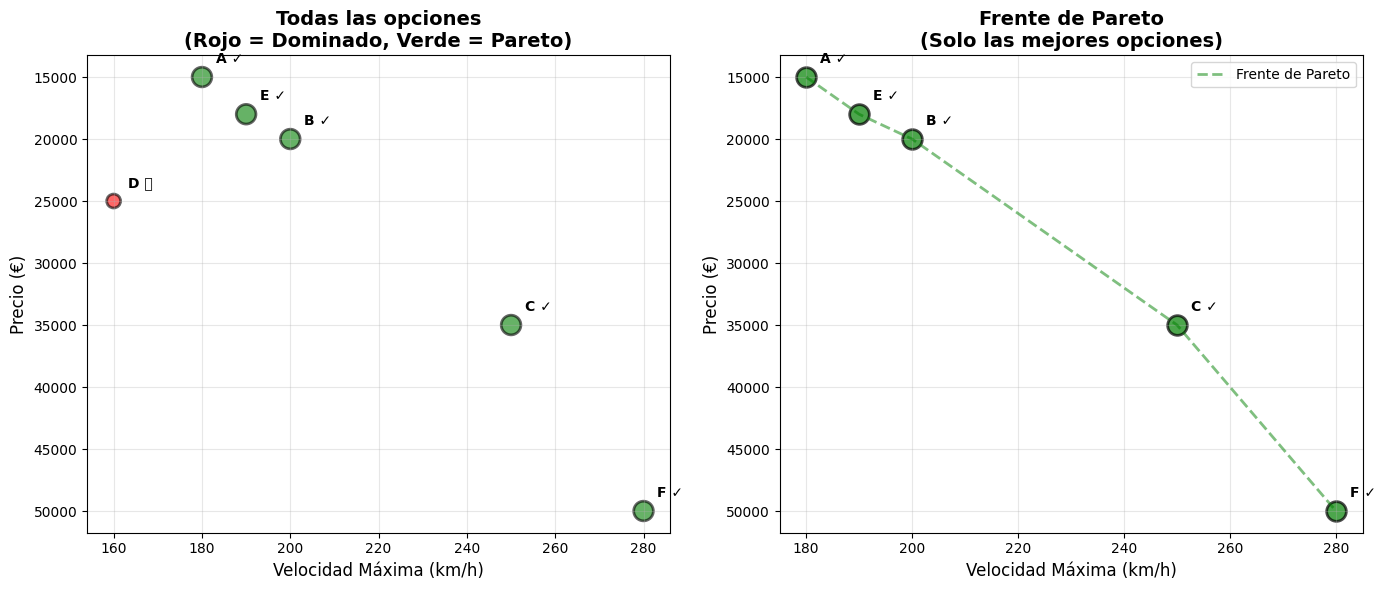

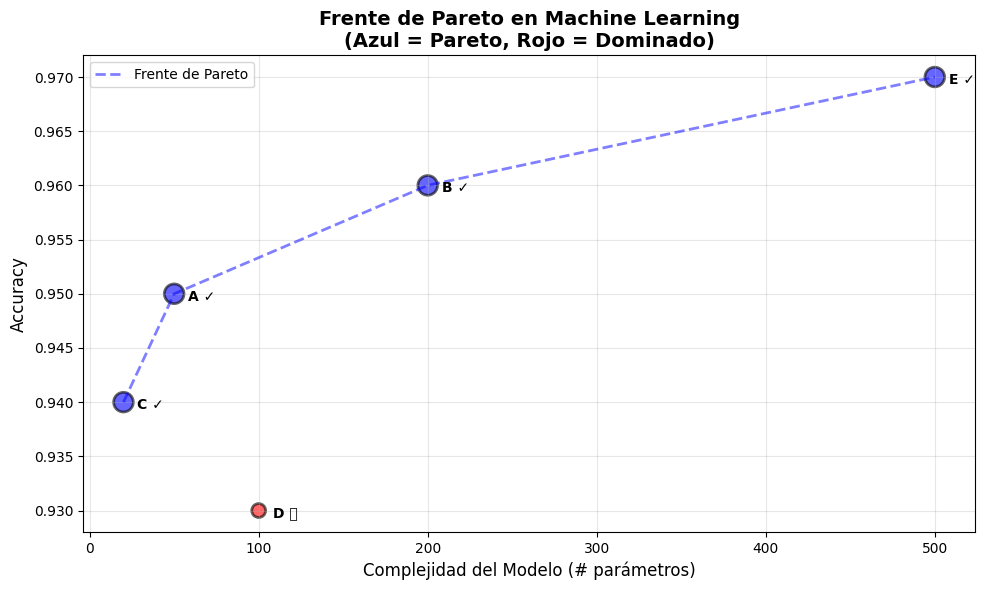

In [18]:
"""
¿Qué es el Frente de Pareto?
============================

Explicación con ejemplos prácticos y visualización
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("FRENTE DE PARETO - Explicación Conceptual")
print("="*70)

print("""
El Frente de Pareto es un concepto de la optimización multi-objetivo que 
identifica las MEJORES SOLUCIONES cuando tienes objetivos en conflicto.

EJEMPLO COTIDIANO: Comprar un coche
====================================

Imagina que quieres comprar un coche considerando dos objetivos:
1. Maximizar la VELOCIDAD MÁXIMA (km/h)
2. Minimizar el PRECIO (€)

Estos objetivos están en CONFLICTO: coches más rápidos suelen ser más caros.

Veamos algunos coches disponibles:
""")

# Datos de ejemplo: coches
coches = {
    'A': {'velocidad': 180, 'precio': 15000, 'nombre': 'Coche A (económico)'},
    'B': {'velocidad': 200, 'precio': 20000, 'nombre': 'Coche B (balanceado)'},
    'C': {'velocidad': 250, 'precio': 35000, 'nombre': 'Coche C (deportivo)'},
    'D': {'velocidad': 160, 'precio': 25000, 'nombre': 'Coche D (MALA OPCIÓN)'},
    'E': {'velocidad': 190, 'precio': 18000, 'nombre': 'Coche E (buena oferta)'},
    'F': {'velocidad': 280, 'precio': 50000, 'nombre': 'Coche F (superdeportivo)'},
}

print("\nCoches disponibles:")
print("-" * 70)
for key, coche in coches.items():
    print(f"{key}: {coche['velocidad']:3d} km/h | €{coche['precio']:,} | {coche['nombre']}")

print("\n" + "="*70)
print("CONCEPTOS CLAVE:")
print("="*70)

print("""
1. DOMINANCIA:
   Una solución A "domina" a B si:
   - A es mejor o igual en TODOS los objetivos
   - A es estrictamente mejor en AL MENOS UN objetivo
   
   Ejemplo: Coche E DOMINA a Coche D porque:
   ✓ E es más rápido (190 > 160)
   ✓ E es más barato (18000 < 25000)
   → El Coche D es una MALA ELECCIÓN (está dominado)

2. NO DOMINANCIA:
   Una solución NO ESTÁ DOMINADA cuando no existe otra que sea mejor
   en todos los objetivos.
   
   Ejemplo: Coche B vs Coche E:
   - E es más barato (18000 < 20000) ✓
   - B es más rápido (200 > 190) ✓
   → Ninguno domina al otro - AMBAS SON BUENAS OPCIONES

3. FRENTE DE PARETO:
   Es el conjunto de TODAS las soluciones NO DOMINADAS.
   Estas son las ÚNICAS opciones que deberías considerar.
""")

# Análisis de dominancia
print("\n" + "="*70)
print("ANÁLISIS DE DOMINANCIA:")
print("="*70)

def domina(coche1, coche2):
    """Retorna True si coche1 domina a coche2"""
    # Para velocidad: queremos maximizar (mayor es mejor)
    # Para precio: queremos minimizar (menor es mejor)
    
    mejor_o_igual_en_todos = (
        coche1['velocidad'] >= coche2['velocidad'] and 
        coche1['precio'] <= coche2['precio']
    )
    
    mejor_en_al_menos_uno = (
        coche1['velocidad'] > coche2['velocidad'] or 
        coche1['precio'] < coche2['precio']
    )
    
    return mejor_o_igual_en_todos and mejor_en_al_menos_uno

# Encontrar soluciones dominadas
dominados = set()
for key1, coche1 in coches.items():
    for key2, coche2 in coches.items():
        if key1 != key2 and domina(coche1, coche2):
            dominados.add(key2)
            print(f"✓ Coche {key1} DOMINA a Coche {key2}")
            print(f"  {key1}: {coche1['velocidad']} km/h, €{coche1['precio']:,}")
            print(f"  {key2}: {coche2['velocidad']} km/h, €{coche2['precio']:,}")
            print()

# Frente de Pareto
frente_pareto = {k: v for k, v in coches.items() if k not in dominados}

print("="*70)
print("FRENTE DE PARETO (soluciones óptimas):")
print("="*70)
for key, coche in frente_pareto.items():
    print(f"✨ Coche {key}: {coche['velocidad']} km/h | €{coche['precio']:,}")

print(f"\n🎯 Soluciones NO dominadas: {', '.join(frente_pareto.keys())}")
print(f"❌ Soluciones dominadas (malas opciones): {', '.join(dominados)}")

print("\n" + "="*70)
print("INTERPRETACIÓN:")
print("="*70)
print("""
El Frente de Pareto te dice: "Estas son las ÚNICAS opciones razonables"

• Si quieres MAXIMIZAR velocidad → Elige Coche F (280 km/h, €50,000)
• Si quieres MINIMIZAR precio → Elige Coche A (180 km/h, €15,000)
• Si quieres BALANCE → Elige B, E o C según tus prioridades

¡Las opciones dominadas (D) NUNCA deberían considerarse!
Hay otra opción que es mejor en TODO.
""")

# Visualización
print("\n" + "="*70)
print("VISUALIZACIÓN GRÁFICA:")
print("="*70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Todos los coches
velocidades = [c['velocidad'] for c in coches.values()]
precios = [c['precio'] for c in coches.values()]
nombres = list(coches.keys())

colors = ['red' if k in dominados else 'green' for k in nombres]
sizes = [100 if k in dominados else 200 for k in nombres]

ax1.scatter(velocidades, precios, c=colors, s=sizes, alpha=0.6, edgecolors='black', linewidths=2)

for i, key in enumerate(nombres):
    label = f"{key}"
    if key in dominados:
        label += " ❌"
    else:
        label += " ✓"
    ax1.annotate(label, (velocidades[i], precios[i]), 
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold')

ax1.set_xlabel('Velocidad Máxima (km/h)', fontsize=12)
ax1.set_ylabel('Precio (€)', fontsize=12)
ax1.set_title('Todas las opciones\n(Rojo = Dominado, Verde = Pareto)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.invert_yaxis()  # Invertir para que menor precio esté arriba

# Gráfico 2: Solo Frente de Pareto
pareto_vel = [coches[k]['velocidad'] for k in frente_pareto.keys()]
pareto_precio = [coches[k]['precio'] for k in frente_pareto.keys()]
pareto_nombres = list(frente_pareto.keys())

# Ordenar por velocidad para conectar con línea
orden = np.argsort(pareto_vel)
pareto_vel_ordenado = [pareto_vel[i] for i in orden]
pareto_precio_ordenado = [pareto_precio[i] for i in orden]
pareto_nombres_ordenado = [pareto_nombres[i] for i in orden]

ax2.plot(pareto_vel_ordenado, pareto_precio_ordenado, 'g--', linewidth=2, alpha=0.5, label='Frente de Pareto')
ax2.scatter(pareto_vel_ordenado, pareto_precio_ordenado, c='green', s=200, alpha=0.7, edgecolors='black', linewidths=2)

for i, key in enumerate(pareto_nombres_ordenado):
    ax2.annotate(f"{key} ✓", (pareto_vel_ordenado[i], pareto_precio_ordenado[i]), 
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold')

ax2.set_xlabel('Velocidad Máxima (km/h)', fontsize=12)
ax2.set_ylabel('Precio (€)', fontsize=12)
ax2.set_title('Frente de Pareto\n(Solo las mejores opciones)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('pareto_front_coches.png', dpi=150, bbox_inches='tight')
print("\n✓ Gráfico guardado: pareto_front_coches.png")

# ============================================================================
# EJEMPLO EN MACHINE LEARNING
# ============================================================================

print("\n\n" + "="*70)
print("FRENTE DE PARETO EN MACHINE LEARNING (TPOT2)")
print("="*70)

print("""
En TPOT2, cuando optimizas múltiples objetivos (ej: Accuracy + Complejidad),
cada PIPELINE es como un "coche":

Pipeline A: 95% accuracy, 50 parámetros
Pipeline B: 96% accuracy, 200 parámetros  
Pipeline C: 94% accuracy, 20 parámetros
Pipeline D: 93% accuracy, 100 parámetros  ❌ (DOMINADO por C)
Pipeline E: 97% accuracy, 500 parámetros

FRENTE DE PARETO en ML:
========================
""")

# Simular pipelines de ML
pipelines_ml = {
    'Pipeline A': {'accuracy': 0.95, 'complexity': 50},
    'Pipeline B': {'accuracy': 0.96, 'complexity': 200},
    'Pipeline C': {'accuracy': 0.94, 'complexity': 20},
    'Pipeline D': {'accuracy': 0.93, 'complexity': 100},  # Dominado
    'Pipeline E': {'accuracy': 0.97, 'complexity': 500},
}

def domina_ml(p1, p2):
    """p1 domina p2 si tiene mejor o igual accuracy y menor o igual complejidad"""
    mejor_o_igual = (
        p1['accuracy'] >= p2['accuracy'] and 
        p1['complexity'] <= p2['complexity']
    )
    mejor_en_uno = (
        p1['accuracy'] > p2['accuracy'] or 
        p1['complexity'] < p2['complexity']
    )
    return mejor_o_igual and mejor_en_uno

# Análisis
dominados_ml = set()
for k1, p1 in pipelines_ml.items():
    for k2, p2 in pipelines_ml.items():
        if k1 != k2 and domina_ml(p1, p2):
            dominados_ml.add(k2)

pareto_ml = {k: v for k, v in pipelines_ml.items() if k not in dominados_ml}

print("Pipelines en el Frente de Pareto:")
for k, p in pareto_ml.items():
    print(f"✨ {k}: Accuracy={p['accuracy']:.2%}, Complejidad={p['complexity']} parámetros")

print(f"\n❌ Dominados: {', '.join(dominados_ml)}")

print("""
¿Cuál elegir?
=============
• ¿Necesitas el MEJOR accuracy? → Pipeline E (97%, 500 params)
• ¿Quieres un modelo SIMPLE? → Pipeline C (94%, 20 params)
• ¿Buscas BALANCE? → Pipeline A o B

¡Pipeline D NUNCA debería usarse! Pipeline C es mejor en todo.
""")

# Visualización ML
fig, ax = plt.subplots(figsize=(10, 6))

# Todos los pipelines
acc_all = [p['accuracy'] for p in pipelines_ml.values()]
comp_all = [p['complexity'] for p in pipelines_ml.values()]
names_all = list(pipelines_ml.keys())

colors_ml = ['red' if k in dominados_ml else 'blue' for k in names_all]
sizes_ml = [100 if k in dominados_ml else 200 for k in names_all]

ax.scatter(comp_all, acc_all, c=colors_ml, s=sizes_ml, alpha=0.6, edgecolors='black', linewidths=2)

for i, name in enumerate(names_all):
    label = f"{name.split()[1]}"
    if name in dominados_ml:
        label += " ❌"
    else:
        label += " ✓"
    ax.annotate(label, (comp_all[i], acc_all[i]), 
                xytext=(10, -5), textcoords='offset points',
                fontsize=10, fontweight='bold')

# Conectar frente de Pareto
pareto_acc = [pipelines_ml[k]['accuracy'] for k in pareto_ml.keys()]
pareto_comp = [pipelines_ml[k]['complexity'] for k in pareto_ml.keys()]

orden_ml = np.argsort(pareto_comp)
pareto_comp_ord = [pareto_comp[i] for i in orden_ml]
pareto_acc_ord = [pareto_acc[i] for i in orden_ml]

ax.plot(pareto_comp_ord, pareto_acc_ord, 'b--', linewidth=2, alpha=0.5, label='Frente de Pareto')

ax.set_xlabel('Complejidad del Modelo (# parámetros)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Frente de Pareto en Machine Learning\n(Azul = Pareto, Rojo = Dominado)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('pareto_front_ml.png', dpi=150, bbox_inches='tight')
print("\n✓ Gráfico guardado: pareto_front_ml.png")

print("\n" + "="*70)
print("RESUMEN FINAL")
print("="*70)
print("""
El Frente de Pareto es crucial en optimización multi-objetivo porque:

1. ✅ ELIMINA opciones subóptimas (dominadas)
2. ✅ PRESENTA solo las mejores alternativas
3. ✅ MUESTRA los trade-offs entre objetivos
4. ✅ PERMITE elegir según tus prioridades específicas

En TPOT2:
---------
• Cuando usas multi-objetivo, TPOT2 mantiene un Frente de Pareto
• Puedes acceder a él con: tpot.pareto_front
• Te da MÚLTIPLES modelos óptimos con diferentes balances
• TÚ decides cuál desplegar según tus necesidades de negocio

¡No existe UNA sola "mejor solución" cuando hay objetivos en conflicto!
El Frente de Pareto te muestra TODAS las mejores opciones.
""")

print("\n✓ Explicación completa")
print("✓ Gráficos guardados en el directorio actual")


# Solución a Problemas Comunes de TPOT2

## ❌ Error: TimeoutError: No valid workers found

### Causa:
TPOT2 usa **Dask** para paralelización, que requiere que el código esté protegido con `if __name__ == "__main__":` para funcionar correctamente en Windows y algunos sistemas Unix.

### Soluciones:

#### ✅ Solución 1: Usar `n_jobs=1` (más simple)

In [ ]:
import tpot2

if __name__ == "__main__":
    tpot = tpot2.TPOTClassifier(
        n_jobs=1,  # Solo un worker, sin paralelización
        max_time_mins=5,
        scorers=['accuracy']
    )
    tpot.fit(X_train, y_train)

**Ventajas:**
- ✅ Funciona siempre
- ✅ No hay problemas de workers
- ✅ Código más simple

**Desventajas:**
- ❌ No usa múltiples cores
- ❌ Más lento

---

#### ✅ Solución 2: Configurar correctamente el multiprocessing

In [ ]:
import multiprocessing
import tpot2

# IMPORTANTE: Poner esto al principio del script
multiprocessing.set_start_method('spawn', force=True)

if __name__ == "__main__":
    tpot = tpot2.TPOTClassifier(
        n_jobs=2,  # Número de workers
        max_time_mins=5
    )
    tpot.fit(X_train, y_train)

#### ✅ Solución 3: Limitar workers con variable de entorno

In [ ]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '2'  # Al principio del script

import tpot2

if __name__ == "__main__":
    tpot = tpot2.TPOTClassifier(n_jobs=2)
    tpot.fit(X_train, y_train)

## 🐛 Otros problemas comunes

### Error: "ModuleNotFoundError: No module named 'tpot2'"

**Solución:**
```bash
pip install tpot2
```

O si tienes TPOT1 instalado:
```bash
pip uninstall tpot
pip install tpot2
```

---

### Error: "LightGBM no funciona"

**Solución con conda (recomendado):**
```bash
conda install -c conda-forge lightgbm
```

**Solución con pip:**
```bash
pip install lightgbm --install-option=--precompile
```

---

### Error: "Memory limit exceeded"

**Solución:** Reducir `memory_limit`
```python
tpot = tpot2.TPOTClassifier(
    memory_limit='2GB',  # En lugar de 4GB
    population_size=10,  # Reducir población
    max_time_mins=5      # Menos tiempo
)
```

---

### Error: "TPOT takes too long"

**Solución:** Reducir parámetros
```python
tpot = tpot2.TPOTClassifier(
    max_time_mins=3,      # Menos tiempo total
    max_eval_time_mins=1, # Menos tiempo por pipeline
    cv=3,                 # Menos folds de CV
    n_jobs=1              # Sin paralelización (más rápido de iniciar)
)
```

---

### Warning: "UserWarning: X does not have valid feature names"

**No es crítico**, pero si quieres eliminarlo:
```python
import warnings
warnings.filterwarnings('ignore')
```

O usa pandas DataFrame:
```python
import pandas as pd
X_df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
tpot.fit(X_df, y)
```

---

## 📋 Checklist para que TPOT2 funcione

- [ ] ✅ Código protegido con `if __name__ == "__main__":`
- [ ] ✅ Imports correctos (tpot2, no tpot)
- [ ] ✅ Usar `n_jobs=1` si hay problemas
- [ ] ✅ Establecer `max_time_mins` razonable (5-10 min para pruebas)
- [ ] ✅ Python 3.8 o superior
- [ ] ✅ Dependencias instaladas (sklearn, numpy, dask, etc.)

---

## 🚀 Configuración recomendada para comenzar

In [ ]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '2'

import tpot2
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

def main():
    # Cargar datos
    X, y = load_digits(return_X_y=True)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Configuración simple y robusta
    tpot = tpot2.TPOTClassifier(
        scorers=['accuracy'],
        cv=3,
        max_time_mins=5,
        max_eval_time_mins=2,
        n_jobs=1,  # Cambiar a 2-4 si no hay problemas
        random_state=42,
        verbose=1
    )
    
    # Entrenar
    tpot.fit(X_train, y_train)
    
    # Evaluar
    print(f"Test accuracy: {tpot.score(X_test, y_test):.4f}")
    
    # Exportar
    tpot.export('best_pipeline.py')

if __name__ == "__main__":
    main()

---

## 💡 Tips adicionales

### Para Windows:
- Usa `n_jobs=1` o `n_jobs=2` (no usar -1)
- Ejecuta desde terminal, no desde IDE interactivo
- Considera usar WSL o conda environment

### Para macOS con M1/M2:
```bash
# Crear environment específico
conda create -n tpot2 python=3.10
conda activate tpot2
conda install -c conda-forge lightgbm xgboost
pip install tpot2
```

### Para Linux:
- Generalmente funciona mejor con `n_jobs=-1`
- Puedes usar más workers sin problemas

---

## 📞 Si nada funciona

1. **Usar la versión simple:**
   ```bash
   python tpot2_mlflow_simple.py
   ```

2. **Probar con un dataset pequeño primero:**
   ```python
   from sklearn.datasets import load_iris
   X, y = load_iris(return_X_y=True)
   ```

3. **Verificar versiones:**
   ```bash
   pip list | grep tpot
   pip list | grep dask
   pip list | grep scikit-learn
   ```

4. **Reinstalar todo:**
   ```bash
   pip uninstall tpot tpot2 dask distributed -y
   pip install tpot2
   ```

---

## ✅ Script de prueba rápida

Crea `test_tpot2.py`:

In [ ]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '1'

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import tpot2

def test():
    X, y = load_iris(return_X_y=True)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    
    tpot = tpot2.TPOTClassifier(
        max_time_mins=1,
        n_jobs=1,
        verbose=1
    )
    
    tpot.fit(X_train, y_train)
    print(f"Score: {tpot.score(X_test, y_test):.2f}")
    print("✓ TPOT2 funciona correctamente!")

if __name__ == "__main__":
    test()

```

Ejecuta:

python test_tpot2.py
```

Si esto funciona, tu instalación está correcta.

---

## 🏋️ 4. Ejercicios Prácticos <a id='4-ejercicios'></a>

### Ejercicio 1: TPOT en el Dataset Wine

Usa el dataset de Vinos (`load_wine` de sklearn) para encontrar el mejor clasificador.

In [ ]:
# TU CÓDIGO AQUÍ
from sklearn.datasets import load_wine

# 1. Cargar datos

# 2. Dividir en train/test

# 3. Ejecutar TPOTClassifier (prueba con 3 generaciones para que sea rápido)

# 4. Evaluar y exportar

### Ejercicio 2: Regresión con TPOT

TPOT también sirve para regresión (predecir números). Usa `TPOTRegressor` con el dataset de Boston Housing (o California Housing) para predecir precios.

*Nota: `fetch_california_housing` suele funcionar mejor que `load_boston` en versiones recientes de sklearn.*

In [ ]:
from tpot import TPOTRegressor
from sklearn.datasets import fetch_california_housing

# TU CÓDIGO AQUÍ